# Sensory Hypersensitivity in Fibromyalgia

Jeremy Barton<br>
Professor Neugebauer<br>
DSC-640 T301<br>
06/28/2026

**Contents**

1. [Introduction & Objective](#introduction)
2. [Data Preparation](#data-prep)
3. [Do fibromyalgia patients differ from controls?](#q1)
4. [Do these sensitivities co-occur?](#q2)
5. [Does symptom intensity depend on age?](#q3)
6. [Supplementary - Predicting group from scores](#model)
7. [Conclusion](#conclusion)

<a id='introduction'></a>
## 1. Introduction & Objective

Fibromyalgia is a chronic condition characterized by widespread pain and heightened sensitivity to stimuli. A growing line of research asks whether that sensitivity is part of a *broader* hypersensitization profile, one that overlaps with the sensory and social traits measured on the autism spectrum. This notebook explores that idea using a case-control dataset of **399 participants** (139 controls, 260 with a fibromyalgia diagnosis).

The objective of the notebook is to determine whether fibromyalgia is accompanied by a broad pattern of sensory and trait-level hypersensitization, and whether that pattern depends on a participant's age.

There are three questions being asked here:

1. <b>Group differences</b>: Do fibromyalgia patients score higher than controls on central sensitization (CSI), sensory sensitivity (SPS), and autistic-like traits (SAT)? This would show whether there is a difference in symptom based on the different groupings.

2. <b>Co-occurrence</b>: Do these three measures rise together *within individuals*, as a single-hypersensitization account would predict?

3. <b>Age</b> Is symptom intensity weaker in younger patients (≤35) than older ones (40+), or is the full profile already present in young adults?

A short supplementary section then asks whether the three scores alone can distinguish patients from controls.

> <b>IMPORTANT NOTE:</b> This is cross-sectional, observational data - a single snapshot of 399 people. It can describe *who differs and how traits relate*, but it cannot establish causation or measure how diagnosis rates have changed over time. The age question below is framed accordingly: it compares younger and older patients *in this sample*, not trends across decades.

<a id='data-prep'></a>
## 2. Data Preparation

The dataset is split across two files. 

`responses.csv` holds the demographics plus the **CSI** (Central Sensitization Inventory, 25 items) and **SPSQ** (Sensory Processing Sensitivity Questionnaire, 16 items). 

The autism measure, **SAT** (Autism Spectrum Quotient, 24 items), lives only in the full Kaggle export `All_data_final.csv`. 

Both files describe the same 399 participants in the same row order, so we attach `SAT_total` after verifying the alignment on `CSI_total`.

#### Imports and Preprocessing

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Making sure to use a consistent style throught
#   this notebook
plt.style.use('default')
sns.set_theme(style='whitegrid', palette='deep')

# Demographics + CSI + SPSQ
response_data = pd.read_csv('data/responses.csv')
# Full export that also contains the SAT (autism) scores
all_data = pd.read_csv('All_data_final.csv')

# Verify the two files line up row-for-row before merging
assert (response_data['CSI_total'].values == all_data['CSI_total'].values).all(), "Files not aligned!"

# Build the analysis frame
df = response_data.copy()
df['SAT_total'] = all_data['SAT_total'].values
df['group_name'] = df['group'].map({0: 'Control', 1: 'Fibromyalgia'})

# Shared definitions used throughout
totals = ['CSI_total', 'SPS_total', 'SAT_total']
labels_full = {'CSI_total': 'Central Sensitization (CSI)',
               'SPS_total': 'Sensory Sensitivity (SPS)',
               'SAT_total': 'Autistic Traits (SAT)'}
palette = {'Control': '#4c9be8', 'Fibromyalgia': '#e8794c'}

print('Shape:', df.shape)
print('\nParticipants per group:')
print(df['group_name'].value_counts())

Shape: (399, 52)

Participants per group:
group_name
Fibromyalgia    260
Control         139
Name: count, dtype: int64


A quick look at the three summary scores by group sets up everything that follows.

In [3]:
summary = df.groupby('group_name')[totals].agg(['mean', 'median']).round(1)
summary

CSI_total        SPS_total        SAT_total       
                  mean median      mean median      mean median
group_name                                                     
Control           37.5   37.0      86.4   90.0      25.8   25.0
Fibromyalgia      71.6   72.0     116.7  118.0      34.2   33.0

The fibromyalgia group already looks higher on all three measures. The next three sections test that impression visually and statistically.

<a id='q1'></a>
## 3. Q1: Do fibromyalgia patients differ from controls?

### 3a. Distribution of autistic-trait scores

Starting with the autism measure, since it is the least obviously tied to fibromyalgia. 

If autistic-like traits are elevated in patients, the fibromyalgia histogram should sit to the right of the control histogram. Dashed lines mark each group's mean.

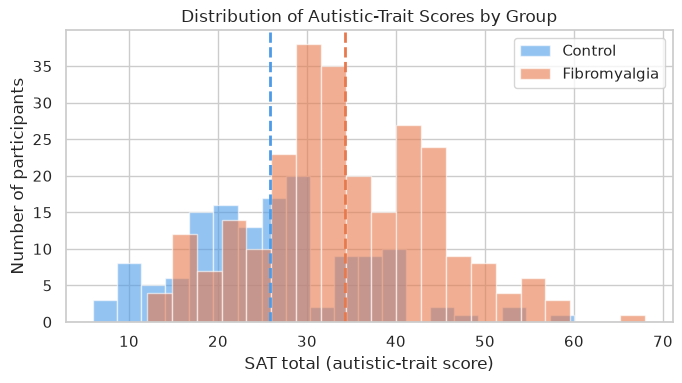

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for grp in ['Control', 'Fibromyalgia']:
    ax.hist(df[df.group_name == grp]['SAT_total'], bins=20, alpha=0.6,
            label=grp, color=palette[grp], edgecolor='white')
    ax.axvline(df[df.group_name == grp]['SAT_total'].mean(),
               color=palette[grp], ls='--', lw=2)
ax.set_xlabel('SAT total (autistic-trait score)')
ax.set_ylabel('Number of participants')
ax.set_title('Distribution of Autistic-Trait Scores by Group')
ax.legend()
plt.tight_layout()
plt.show()

The distributions overlap heavily. Autistic-like traits are common in both groups, but the fibromyalgia distribution is clearly shifted right, with a higher mean. 

Elevated autistic traits are not *unique* to fibromyalgia, but they are more common and more intense in that group. This finding aligns well with the previous visualization of the median fibro scores tending to be higher than the control.

### 3b. All three measures by group

A boxplot per measure lets us compare medians, spread, and outliers side by side. A Mann-Whitney U test (printed below) checks whether each group difference is statistically reliable.

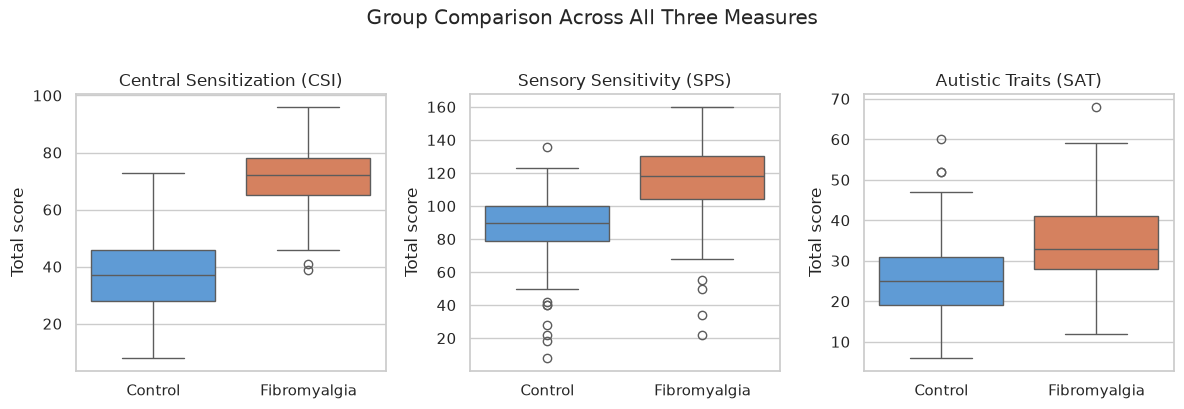

Mann-Whitney U test (Fibromyalgia > Control):
  CSI_total  : Fibro median=72, Control median=37, p = 1.28e-55
  SPS_total  : Fibro median=118, Control median=90, p = 5.83e-33
  SAT_total  : Fibro median=33, Control median=25, p = 9.49e-15


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Iterating through the subplots that make up
#   the three visualzations shown below
for ax, col in zip(axes, totals):
    sns.boxplot(data=df, x='group_name', y=col, ax=ax,
                hue='group_name', palette=palette, legend=False)
    ax.set_title(labels_full[col])
    ax.set_xlabel('')
    ax.set_ylabel('Total score')
fig.suptitle('Group Comparison Across All Three Measures', y=1.02)
plt.tight_layout()
plt.show()

# Titling the table
print('Mann-Whitney U test (Fibromyalgia > Control):')
for col in totals:
    c = df[df.group == 0][col] # marking control rows
    f = df[df.group == 1][col] # marking fibro rows
    _, p = stats.mannwhitneyu(f, c, alternative='greater')
    print(f'  {col:11s}: Fibro median={f.median():.0f}, '
          f'Control median={c.median():.0f}, p = {p:.2e}')

Every fibromyalgia box sits well above its control counterpart, and all three differences are statistically significant (p < 0.001). 

The gap is largest for central sensitization which is expected, since the CSI is essentially the fibromyalgia screening instrument, but the same upward shift holds for sensory sensitivity and for autistic traits.

<b>ANSWER TO QUESTION #1: Yes, fibromyalgia patients score higher on all three tests.</b>

<a id='q2'></a>
## 4. Do these sensitivities co-occur?

### 4a. Bivariate plot: central sensitization vs autistic traits

Group differences tell us the averages move together; this asks whether the traits move together *within individuals*. Each point is one participant, colored by group, with a least-squares line fit within each group.

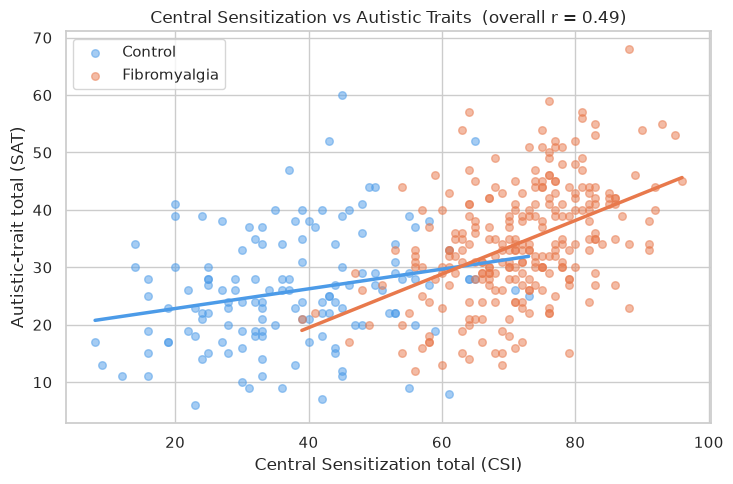

Control      : r = 0.24, p = 5.10e-03, n = 139
Fibromyalgia : r = 0.45, p = 1.16e-14, n = 260


In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for grp in ['Control', 'Fibromyalgia']:
    sub = df[df.group_name == grp]
    ax.scatter(sub['CSI_total'], sub['SAT_total'], alpha=0.5,
               color=palette[grp], label=grp, s=30)
    m, b = np.polyfit(sub['CSI_total'], sub['SAT_total'], 1)
    xs = np.linspace(sub['CSI_total'].min(), sub['CSI_total'].max(), 50)
    ax.plot(xs, m * xs + b, color=palette[grp], lw=2.5)

r_all, _ = stats.pearsonr(df['CSI_total'], df['SAT_total'])
ax.set_xlabel('Central Sensitization total (CSI)')
ax.set_ylabel('Autistic-trait total (SAT)')
ax.set_title(f'Central Sensitization vs Autistic Traits  (overall r = {r_all:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

for grp in ['Control', 'Fibromyalgia']:
    sub = df[df.group_name == grp]
    r, p = stats.pearsonr(sub['CSI_total'], sub['SAT_total'])
    print(f'{grp:13s}: r = {r:.2f}, p = {p:.2e}, n = {len(sub)}')

Participants who score higher on central sensitization tend to score higher on autistic traits (overall r = 0.49). The fibromyalgia cloud sits up and to the right of the controls, and its regression line is **steeper** (r = 0.46 vs 0.24 for controls) - the two traits track each other more tightly among patients.

### 4b. Correlation heatmap - all three measures

Generalizing beyond the single CSI-SAT pair: are *all* three measures positively related?

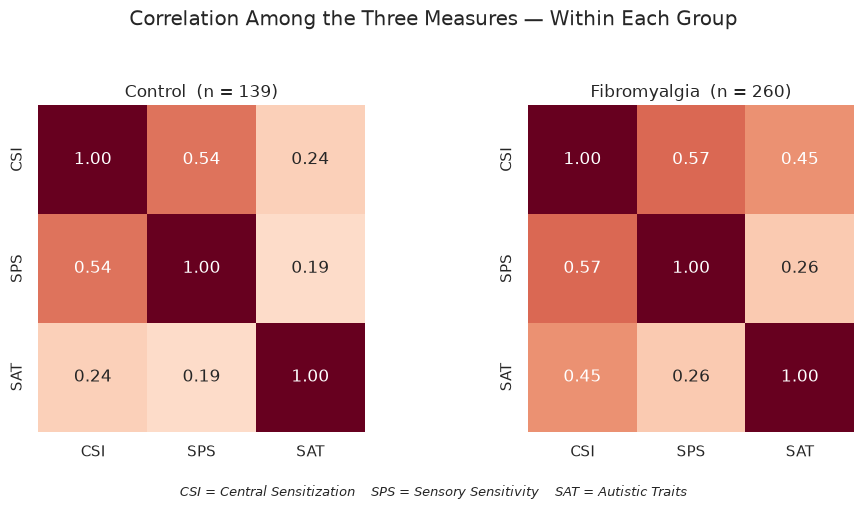

In [7]:
# 4b (revised): correlation within each group, not pooled.
labels_short = {'CSI_total': 'CSI', 'SPS_total': 'SPS', 'SAT_total': 'SAT'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, grp in zip(axes, ['Control', 'Fibromyalgia']):
    corr = df[df.group_name == grp][totals].corr()
    sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                xticklabels=[labels_short[c] for c in totals],
                yticklabels=[labels_short[c] for c in totals],
                ax=ax, fmt='.2f', square=True, cbar=False)
    n = (df.group_name == grp).sum()
    ax.set_title(f'{grp}  (n = {n})')

fig.suptitle('Correlation Among the Three Measures — Within Each Group', y=1.04)

# Key: define the abbreviations once, below the figure
fig.text(0.5, -0.04,
         'CSI = Central Sensitization    SPS = Sensory Sensitivity    SAT = Autistic Traits',
         ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

All three measures are positively correlated, with no negative relationships. CSI and SPS are most tightly linked (r = 0.72) - both tap general hypersensitivity - while autistic traits correlate moderately with each. This is consistent with a single underlying *hypersensitization* dimension running through all three instruments.

**ANSWER TO Question 2:** Yes, the measures co-occur within individuals, most strongly inside the fibromyalgia group.

<a id='q3'></a>
## 5. Question 3: Does symptom intensity depend on age?

This is the question the project originally set out to probe: is fibromyalgia mainly an *older-adult* condition, or is the full symptom profile already present in young patients? We approach it three ways - the overall age distribution, a direct younger-vs-older comparison, and age plotted against symptom intensity.

### 5a. Age distribution by group

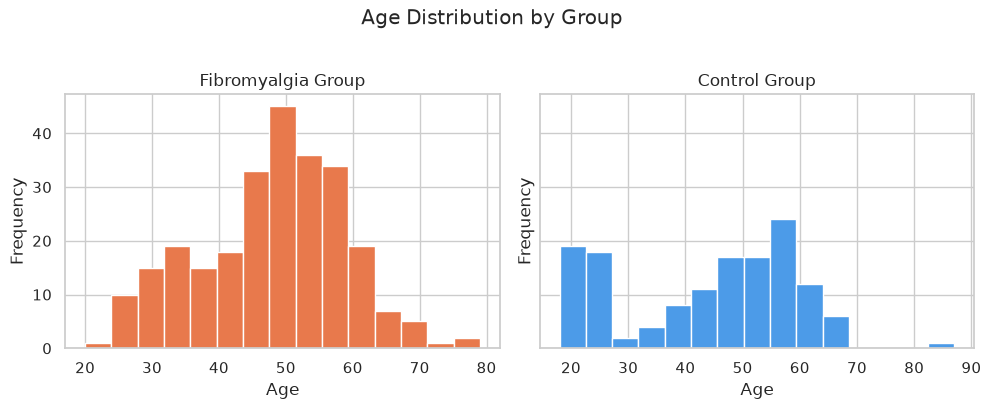

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (grp, gnum) in zip(axes, [('Fibromyalgia', 1), ('Control', 0)]):
    ax.hist(df[df.group == gnum]['age'], bins=15,
            color=palette[grp], edgecolor='white')
    ax.set_title(f'{grp} Group')
    ax.set_xlabel('Age')
    ax.set_ylabel('Frequency')
fig.suptitle('Age Distribution by Group', y=1.02)
plt.tight_layout()
plt.show()

Both groups span roughly 18-87 with medians near 48-49. Patients are not dramatically older than controls; the study deliberately recruited a wide age range, which lets us compare younger and older patients directly.

### 5b. Younger (≤35) vs older (40+) fibromyalgia patients

This is the core test. If symptoms intensify with age, the older bars should tower over the younger ones. Median scores are shown with a Mann-Whitney p-value above each pair.

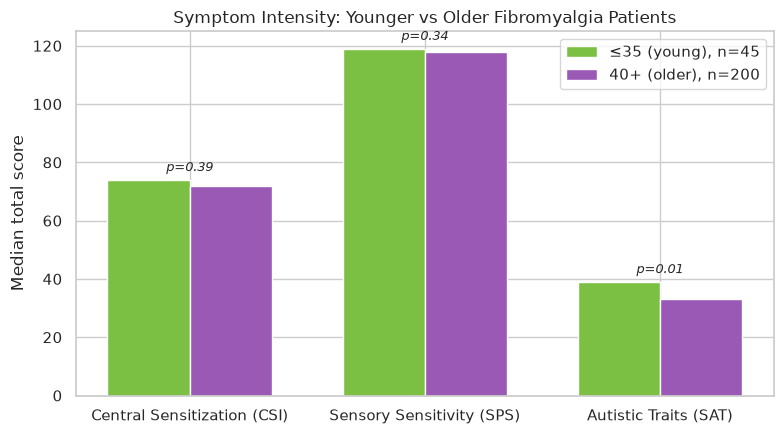

In [9]:
fib = df[df.group == 1].copy()
fib['age_band'] = np.where(fib.age <= 35, '≤35 (young)',
                   np.where(fib.age >= 40, '40+ (older)', '36-39'))
band = fib[fib.age_band.isin(['≤35 (young)', '40+ (older)'])]

order = ['≤35 (young)', '40+ (older)']
med = band.groupby('age_band')[totals].median().loc[order]
n_young = (band.age_band == '≤35 (young)').sum()
n_old = (band.age_band == '40+ (older)').sum()

x = np.arange(len(totals)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, med.loc['≤35 (young)'], w,
       label=f'≤35 (young), n={n_young}', color='#7bc043')
ax.bar(x + w/2, med.loc['40+ (older)'], w,
       label=f'40+ (older), n={n_old}', color='#9b59b6')
ax.set_xticks(x)
ax.set_xticklabels([labels_full[c] for c in totals])
ax.set_ylabel('Median total score')
ax.set_title('Symptom Intensity: Younger vs Older Fibromyalgia Patients')
ax.legend()
for i, col in enumerate(totals):
    yo = band[band.age_band == '≤35 (young)'][col]
    ol = band[band.age_band == '40+ (older)'][col]
    _, p = stats.mannwhitneyu(ol, yo, alternative='two-sided')
    ax.text(i, max(med[col]) + 3, f'p={p:.2f}', ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

For central sensitization and sensory sensitivity, the younger and older bars are essentially identical (p = 0.39 and 0.34 - no significant difference). For autistic traits, the *younger* patients actually score higher (p = 0.01). In other words, the hypersensitization profile is fully present in patients 35 and under - it is not something that builds up only with age.

### 5c. Age vs symptom intensity

The scatter is essentially a flat cloud - age and symptom intensity are uncorrelated overall (r ≈ 0.06), and the two group bands are separated by *condition*, not by age. Symptom intensity does not climb with age.

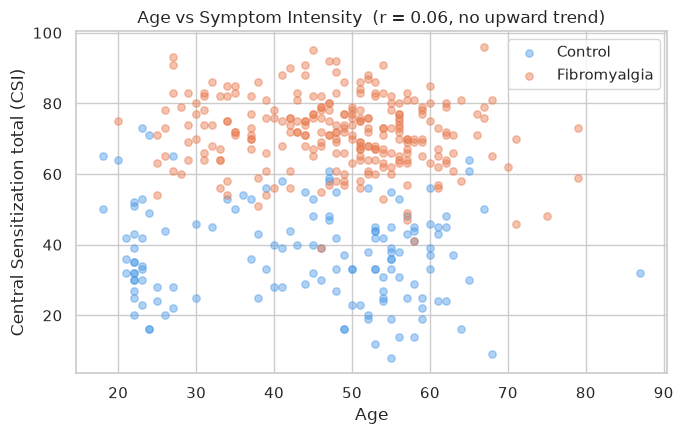

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for grp, gnum in [('Control', 0), ('Fibromyalgia', 1)]:
    sub = df[df.group == gnum]
    ax.scatter(sub.age, sub.CSI_total, alpha=0.45,
               color=palette[grp], label=grp, s=28)
r_age, p_age = stats.pearsonr(df['age'], df['CSI_total'])
ax.set_xlabel('Age')
ax.set_ylabel('Central Sensitization total (CSI)')
ax.set_title(f'Age vs Symptom Intensity  (r = {r_age:.2f}, no upward trend)')
ax.legend()
plt.tight_layout()
plt.show()

<b>ANSWER TO Q3:</b> No, symptom intensity does **not** depend meaningfully on age. 

Younger patients are just as affected as older ones, which is consistent with fibromyalgia being fully present in young adults, though this snapshot cannot speak to whether diagnosis rates have changed over time.

<a id='model'></a>
## 6. Supplementary: Predicting group from scores

If the three measures really capture a fibromyalgia-related hypersensitization profile, they should be able to *distinguish* patients from controls on their own. A logistic regression with 5-fold cross-validation tests exactly that.

5-fold cross-validated accuracy: 93.0%
5-fold cross-validated AUC:      0.974


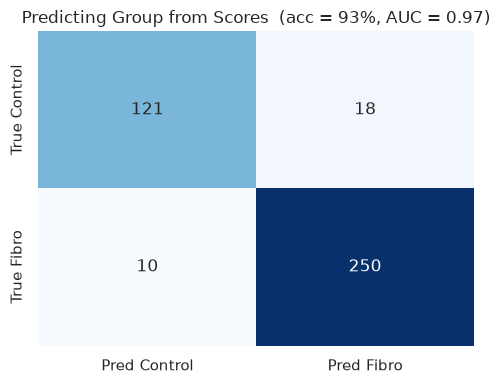

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, roc_auc_score

X = df[totals].values
y = df['group'].values

clf = LogisticRegression(max_iter=1000)
proba = cross_val_predict(clf, X, y, cv=5, method='predict_proba')[:, 1]
pred = (proba >= 0.5).astype(int)

acc = (pred == y).mean()
auc = roc_auc_score(y, proba)
print(f'5-fold cross-validated accuracy: {acc:.1%}')
print(f'5-fold cross-validated AUC:      {auc:.3f}')

cm = confusion_matrix(y, pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Control', 'Pred Fibro'],
            yticklabels=['True Control', 'True Fibro'], ax=ax)
ax.set_title(f'Predicting Group from Scores  (acc = {acc:.0%}, AUC = {auc:.2f})')
plt.tight_layout()
plt.show()

Using only the three total scores, the model separates fibromyalgia patients from controls with about **93% accuracy** and an AUC near **0.97** - strong evidence that the hypersensitization profile (sensory + central + autistic-trait) is a genuine, measurable signature of the condition rather than noise.

<a id='conclusion'></a>
## 7. Conclusion

All three guiding questions resolve into one consistent message. Fibromyalgia patients score significantly higher than controls on central sensitization, sensory sensitivity, and autistic-like traits (all p < 0.001), and those measures rise together within individuals, strongest for the central-sensitization/autistic-trait link inside the patient group (r = 0.46) which points to a shared hypersensitization dimension rather than three separate symptoms. 

The profile is also age-independent. Younger patients match or exceed older ones, so it's already fully present in young adults. Taken together, and with the three scores alone classifying patients versus controls at roughly 93% accuracy (AUC 0.97), the data support the central idea that fibromyalgia is accompanied by a broad sensory-and-trait hypersensitization overlapping with autistic-like traits, not confined to older patients.

The usual caveats apply too. The data are observational and cross-sectional, so they show association rather than causation; the elevated autistic-trait scores may partly reflect overlap between the questionnaires themselves; and with the sample roughly 92% female, the pattern may not extend to men. A natural next step would be to model SAT_total from the CSI and SPS subscores while controlling for age, sex, and group.